This Document is available in Jupyter Notebook format, see [BenjaminFosters/ScientificComputing-Course-B29 @ GitHub | Assurance of Learning/Regression & Interpolation, Taylor Series, Root of Equations.ipynb](https://github.com/BenjaminFosters/ScientificComputing-Course-B29/blob/main/Assurance%20of%20Learning/Regression%20%26%20Interpolation%2C%20Taylor%20Series%2C%20Root%20of%20Equations.ipynb)

To render this to PDF, install Pandoc with pdfLaTeX and plugins (for Fedora Linux 44 based system use `sudo dnf install texlive-scheme-medium`), and use VSCode:

- Press Ctrl/Cmd+Shift+P
- Select option for **Jupyter: Export to PDF**

If you see things like `\newpage`, chances are those are LaTeX & Pandoc, not for Jupyter Notebook.

---

Or clone the repository and open the Notebook to run this document interactively.

Thank You

<!-- Part of this is designated for Pandoc pdfLaTeX and tagged with cell-hide -->

\newpage

\tableofcontents

\newpage

<!-- END OF DESIGNATION -->


# Identity

- Name
  - Ruben Wealth Hu
- Class
  - LC20 (Lecture)
  - BE20 (Lab)
- Student ID
  - 2902583383


# System Environment

This is the system environment used for the course:

- Fedora Linux 44 (Workstation Edition)
- Visual Studio Code (Microsoft Branded)
- Python 3.14.5 (with Virtual Environment)


## Installing Python Libraries


In [1]:
%pip install --upgrade pip
%pip install pandas matplotlib numpy
# Anything starts with % allows you to run shell commands in Jupyter Notebook.

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


\newpage


# Study Case

So I'm a Data Scientist at ALPEN, a Malang-based outdoor equipment manufacturer in Malang.

I'm given a task to process data on ALPEN warehouse capacity, 12 years worth of data (_January 2014 - January 2026_) grouped monthly.

The data itself is in CSV format (a.k.a. Comma-Separated Value), there are 4 things needs to be done.


## Finding the Trend Data and Make the Mathematical Model out of it

Based on the AoL assignment, Quote:

> "You must find the trend on the bag’s production from the data. You must provide a mathematical model that can explain the production’s trend accurately. Since your supervisor want an accurate model, you must avoid any linear approach to build the trend model. This means that you cannot model the trend as a linear function. However, higher degree polynomials or any other function can be used to model the trend. You MUST provide the exact mathematical model of the trend."


First of all, we can start by importing the data, [ALPEN_Production_Data.csv](ALPEN_Production_Data.csv) by using Pandas module for Python.


In [2]:
import pandas as pd
df = pd.read_csv("ALPEN_Production_Data.csv")

# For better experience, you can use Data Wrangler by Microsoft to explore the DF
df

,Month,Production_Units
0,14-Jan,2260
1,14-Feb,2156
2,14-Mar,2214
3,14-Apr,2197
4,14-May,2016
...,...,...
140,25-Sep,29190
141,25-Oct,29719
142,25-Nov,30389
143,25-Dec,30850


As you can see here, we got the data. But there is a problem, technically we can't use the month as it is, we need to serialize it.

Fortunately, the months are already sorted, so all we need to do...


In [3]:
df['Time'] = range(1, len(df) + 1)
df

,Month,Production_Units,Time
0,14-Jan,2260,1
1,14-Feb,2156,2
2,14-Mar,2214,3
3,14-Apr,2197,4
4,14-May,2016,5
...,...,...,...
140,25-Sep,29190,141
141,25-Oct,29719,142
142,25-Nov,30389,143
143,25-Dec,30850,144


On side note, I also wondered how the data looks like, so I decided to add a plot to the mix.


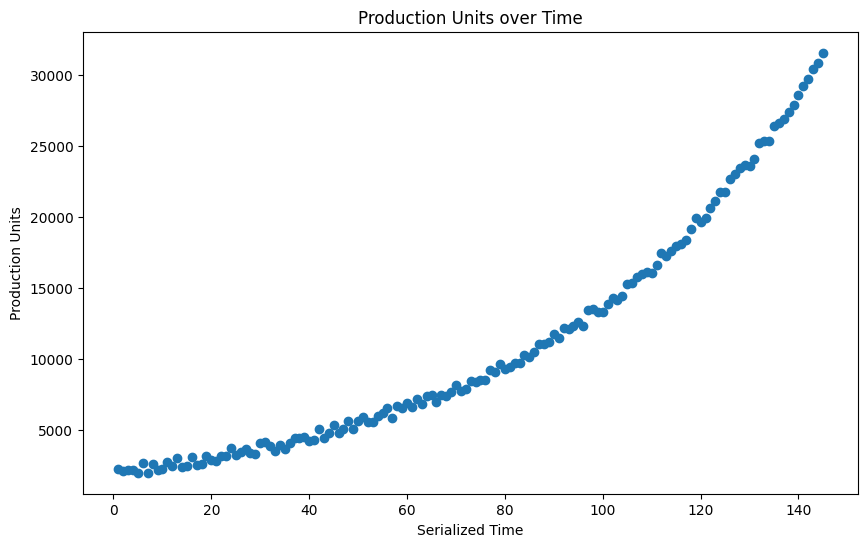

In [4]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.scatter(df['Time'], df['Production_Units'])
plt.xlabel('Serialized Time')
plt.ylabel('Production Units')
plt.title('Production Units over Time')
plt.show()

Next, we need to determine non-linear data regression technique, the reason is due to insufficient accuracy required, exactly what the assignment asked for.

> "Since your supervisor want an accurate model, you must avoid any linear approach to build the trend model. This means that you cannot model the trend as a linear function."

> "However, higher degree polynomials or any other function can be used to model the trend."

I decided to use **Quadratic Polynomial** regression model. Which has the general form of

$$y = ax^2 + bx + c$$

- $x$ is serialized time
- $y$ is production unit
- $a, b, c$ being part of regression coefficients

The main reason we use quadratic (or 2nd degree regression) is because it's non-linear regression technique. We can use cubic regression, but the data itself doesn't need to be extremely accurate, plus higher degree could picked up "noises" in the data, which requires fine-tuning.

Plus, it's good and fast enough to be processed for most machines. In Python we can use NumPy's polynomial function (`numpy.polyfit`)


In [5]:
import numpy as np

x = df['Time']
y = df['Production_Units']

a, b, c = np.polyfit(x, y, 2)

print(f"Quadratic: y = {a:.3f}x^2 + {b:.3f}x + {c:.3f}")

Quadratic: y = 1.588x^2 + -48.030x + 3295.480


We use 3 digit precision for the coefficients, following student requirements of using $\times 10 ^ {-3}$ precision.

Here's the mathematical model:

$$y = 1.588x^2 + -48.030x + 3295.480$$


## Make the Model Computable

The model is now technically computable, but we need to make it more "usable" for the supervisor, so we can make a function out of it.


In [6]:
def predict_production(time):
    # y = 1.588x^2 + -48.030x + 3295.480
    return 1.588 * time**2 + -48.030 * time + 3295.480

Which we can use to predict the number of production units for any given month, by using the serialized time as the input.


In [7]:
print(f"Predicted production for month 13: {predict_production(13):.2f} units")

Predicted production for month 13: 2939.46 units


#### Accuracy Comparison with Actual Data

I also wondered the accuracy of the model, so I decided to compare the predicted data with the actual data, and here is the result.


##### Actual vs Predicted Data Graph


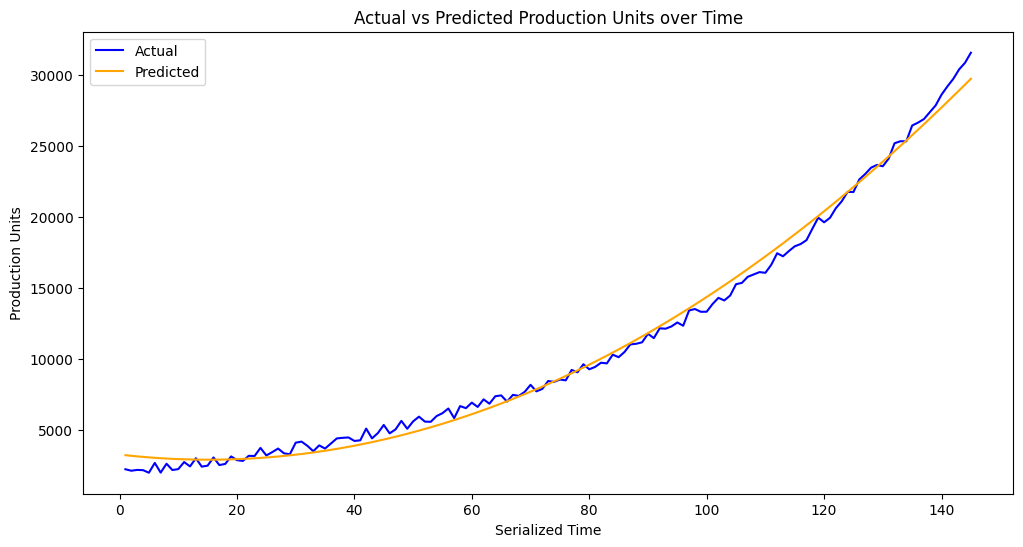

In [8]:
accuracy = pd.DataFrame({
    'Time': df['Time'],
    'Actual': df['Production_Units'],
    'Predicted': a * df['Time'] ** 2 + b * df['Time'] + c
})

plt.figure(figsize=(12, 6))
plt.plot(accuracy['Time'], accuracy['Actual'], label='Actual', color='blue')
plt.plot(accuracy['Time'], accuracy['Predicted'], label='Predicted', color='orange')
plt.xlabel('Serialized Time')
plt.ylabel('Production Units')
plt.title('Actual vs Predicted Production Units over Time')
plt.legend()
plt.show()

##### Top 5 most accurate data points (predicted vs actual)


In [9]:
accuracy['Error'] = abs(accuracy['Actual'] - accuracy['Predicted'])
accuracy.sort_values('Error', inplace=True)
print(accuracy.head(5))

     Time  Actual     Predicted      Error
123   124   21768  21763.127628   4.872372
65     66    7018   7044.614407  26.614407
73     74    8405   8439.391552  34.391552
67     68    7419   7374.247815  44.752185
89     90   11789  11838.893947  49.893947


##### And 5 with most error (predicted vs actual)


In [10]:
accuracy.sort_values('Error', inplace=True, ascending=False)
print(accuracy.head(5))

     Time  Actual     Predicted        Error
144   145   31560  29727.410907  1832.589093
143   144   30850  29316.391192  1533.608808
142   143   30389  28908.548289  1480.451711
141   142   29719  28503.882200  1215.117800
109   110   16079  17231.924638  1152.924638


##### Average Error Rate


In [11]:
accuracy['ErrorInPercentage'] = (accuracy['Error'] / accuracy['Actual']) * 100
print(f"Average Error Rate: {accuracy['ErrorInPercentage'].mean():.2f}%")

Average Error Rate: 8.34%


So, after doing evaluation on accuracy, I can conclude that the model do have pretty high amount of error rate, being at 8.3% average error rate.


## How much time they have before new warehouse is needed?

So ALPEN facility do have space accounted for 35,000 production units each month, and it's estimated we probably need 18 months which...


In [12]:
future_time = 145 + 18
print(predict_production(future_time))

37658.162000000004


is half right. It's clearly overshoot.

But we can use Root Equation technique to find the exact time when the production units will reach 35,000 units, by using the function we created earlier.

NumPy also have a function for this, which is `numpy.roots` function, which can find the roots of a polynomial equation. We can rearrange the equation to be in the form of $f(x) = 0$ and then find the roots.

Why? Because of this:

Yes, we have hard limit that is 35,000 production units, so the formula would be more less...

$$y = 1.588x^2 + -48.030x + 3295.480 = 35000$$

Which can be rearranged to:

$$y = 1.588x^2 + -48.030x + (3295.480 - 35000) = 0$$


In [13]:
roots = np.roots([a, b, c - 35000])
print(f"Roots: {roots}")

last_time = df['Time'].iloc[-1]

valid_roots = [
    root.real # Value Type
    for root in roots # Iteration
    if np.isreal(root) and root.real > last_time # Condition
]

minimum_valid_root = min(valid_roots)
print(f"Minimum valid root: {minimum_valid_root:.2f}")


from math import ceil
root = ceil(minimum_valid_root)
print(f"Rounded up root (months): {root}")

Roots: [ 157.20520983 -126.96750336]
Minimum valid root: 157.21
Rounded up root (months): 158


First of all, we find root with np.root.
But then we get two roots, which are months that equals to roughly 35,000 units. We can test it!


In [14]:
for temp in roots:
    print(f"Testing root {temp:.2f}: Predicted production = {predict_production(temp):.2f} units")

Testing root 157.21: Predicted production = 34989.92 units
Testing root -126.97: Predicted production = 34993.48 units


But since we need months that is more than the last data point (which is 145 months). We need to compare these months too.

In this case, 157.21 months is >= 145 months.

---

But why finding the minimum out of the roots?

During code review with GPT 5.5, it was recommended for code safety. In case we ever used higher degree polynomial (like cubic or quartic), which there's a possibility of getting 2 or more roots.

In that case, we need to find the minimum, the one which is closer to the last month data point.

---

And then since we measure in months as the smallest unit, we can round it up to the approximate nearest month.

We need to round up, since that's when the month hits the threshold ($y > 35000$).

---

Obviously, they're asking for months in human readable format, so we can convert it to years and months format.


In [15]:
start_date = pd.to_datetime(df["Month"].iloc[0], format="%y-%b")
end_date = start_date + pd.DateOffset(months=root)
print(f"Estimated month when production reaches 35,000 units: {end_date.strftime('%Y-%b')}")

Estimated month when production reaches 35,000 units: 2027-Mar


Approximately, the production will reach 35,000 units in **2027 March**.

and we're offset by how many months actually? Python, gimme that answer!


In [16]:
og_month_pred = last_time + 18

print(f"It's {abs(og_month_pred - last_time)} months Benji. (OG: {18} VS Predicted: {og_month_pred - last_time})")

It's 18 months Benji. (OG: 18 VS Predicted: 18)


So it's correct... The early assumption that is.

But at least we got to learn how to find the exact time when the production will reach 35,000 units, which is pretty cool.


## Get it to Python Jupyter Notebook

We'll we did, so cross the list.


## Bonus! What happened in 2029?

I'm BINUSIAN 2029, so I wonder what will happen in 2029, which is my expected graduation year. so let's take a look!

Yes, this is made by GPT 5.5. (_I was near the deadline!_)


In [17]:
new_grad = df.copy()
new_grad["Date"] = pd.to_datetime(new_grad["Month"], format="%y-%b")
new_grad["Data_Type"] = "Actual"

last_date = new_grad["Date"].iloc[-1]
last_time = new_grad["Time"].iloc[-1]

end_date = pd.Timestamp("2029-01-01")

future_dates = pd.date_range(
    start=last_date + pd.DateOffset(months=1),
    end=end_date,
    freq="MS"
)

future_grad = pd.DataFrame({
    "Date": future_dates
})

future_grad["Month"] = future_grad["Date"].dt.strftime("%y-%b")
future_grad["Time"] = range(last_time + 1, last_time + 1 + len(future_grad))
future_grad["Production_Units"] = future_grad["Time"].apply(predict_production)
future_grad["Data_Type"] = "Predicted"

new_grad = pd.concat([new_grad, future_grad], ignore_index=True)

new_grad

,Month,Production_Units,Time,Date,Data_Type
0,14-Jan,2260.000,1,2014-01-01,Actual
1,14-Feb,2156.000,2,2014-02-01,Actual
2,14-Mar,2214.000,3,2014-03-01,Actual
3,14-Apr,2197.000,4,2014-04-01,Actual
4,14-May,2016.000,5,2014-05-01,Actual
...,...,...,...,...,...
176,28-Sep,44544.622,177,2028-09-01,Predicted
177,28-Oct,45060.332,178,2028-10-01,Predicted
178,28-Nov,45579.218,179,2028-11-01,Predicted
179,28-Dec,46101.280,180,2028-12-01,Predicted


So it's 46626.518 in January 29. And here's the chart.


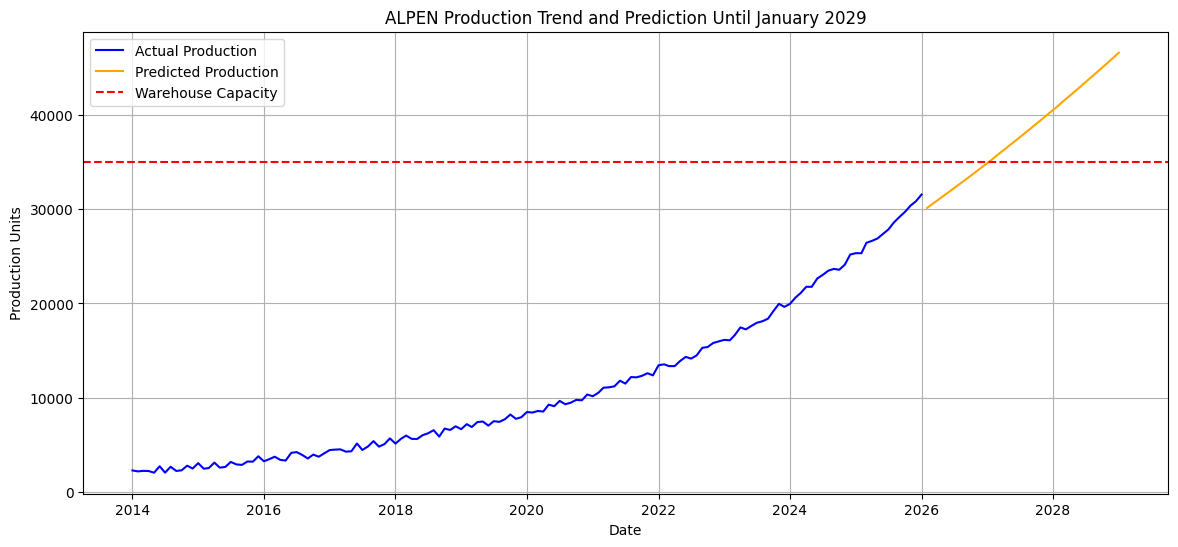

In [18]:
import matplotlib.pyplot as plt

actual_data = new_grad[new_grad["Data_Type"] == "Actual"]
predicted_data = new_grad[new_grad["Data_Type"] == "Predicted"]

plt.figure(figsize=(14, 6))

plt.plot(
    actual_data["Date"],
    actual_data["Production_Units"],
    label="Actual Production",
    color="blue"
)

plt.plot(
    predicted_data["Date"],
    predicted_data["Production_Units"],
    label="Predicted Production",
    color="orange"
)

plt.axhline(
    y=35000,
    color="red",
    linestyle="--",
    label="Warehouse Capacity"
)

plt.xlabel("Date")
plt.ylabel("Production Units")
plt.title("ALPEN Production Trend and Prediction Until January 2029")
plt.legend()
plt.grid(True)

plt.show()

# Conclusion

We got to learn regression techniques, interpolation, and root of equations. We also got to apply it in real world case, which is pretty fun.

Thanks for reading, and see you next semester!

(Special thanks to **Mrs. Anita Rahayu**, **Ir. Simeon Prasetyo** and **Lab Assistant** for the guidance and support throughout the course!)
